# PRW dataset layer — M2 gate

Working notebook for the **first implementation step**: read the raw PRW distribution, assert it, and freeze the two artifacts every later component depends on (`id_map.json`, `split_v1.json`).

Nothing here trains anything. The point is to fail loudly *now* rather than debug a silent data bug after 20 GPU-hours — all three prior student projects hand-rolled this layer ad hoc and two of the three shipped data bugs.

All logic lives in `src/`; this notebook only calls it and displays the results.

| module | role |
|---|---|
| `src/prw_dataset.py` | `.mat` / `query_info.txt` → `FrameAnn`, `Query`, id map |
| `src/src.sanity_check.py` | fatal asserts, statistics table, distributions, GT overlay figure |
| `src/make_split.py` | identity-coverage-aware train/val split |

## 0. Running this on Colab

The detector needs a GPU, so the training runs happen on Colab. The dataset does not: **2.7 GB of frames plus 25,689 files** cannot be re-uploaded per session, and Google Drive charges a round trip per file — copying `data/` there file by file takes hours, and reading it back through the FUSE mount is worse, because the 11,816 annotation `.mat` files are ~300 bytes each.

So the data moves **once**, as a single archive:

```bash
python tools/pack_data.py --out PRW.zip     # locally, from the repo root
```

`PRW.zip` holds `data/**` *and* `cache/*.npz` (stored, not deflated — JPEGs are already compressed). The `.npz` files are the parsed form of all 11,816 annotation files: 512 KB, no absolute paths inside, and with them present the notebook never opens `data/annotations/` at all. Upload that one file to `MyDrive/ml4cv/`.

The cell below then, on Colab only: mounts Drive, clones this repo, copies the archive to the **local SSD** and unpacks it there. Frames are never read through the Drive mount during training — at ~10–100 ms per file open the dataloader would starve the GPU.

**Private repo → the clone needs a token.** Git has no terminal to ask for credentials on inside Colab, so an anonymous clone of a private repo just exits 128. Create a fine-grained GitHub PAT with *Contents: read* on this repository, add it in Colab's **secrets panel** (the key icon in the left sidebar) under the name `GITHUB_TOKEN`, and switch on *Notebook access*. The token is only ever spliced into the clone URL and is masked out of any error message.

Checkpoints are the one thing that does live on Drive (`CKPT_DIR`), because Colab runtimes die: `train_detector` writes `last.pt` every epoch and resumes from it, so a disconnect costs one epoch instead of the whole run.

Locally the cell does nothing and everything keeps its current relative paths. Runtime → Change runtime type → **T4 GPU** before running.

In [ ]:
# Colab bootstrap -- a no-op when this notebook runs locally.
import os
import subprocess
import time

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/MScaramuzzi/person-search-assignment.git"
REPO_BRANCH = "colab-test"
REPO_DIR = "/content/person-search-assignment"
DRIVE_DIR = "/content/drive/MyDrive/ml4cv"  # where PRW.zip was uploaded
ZIP_NAME = "PRW.zip"

CKPT_DIR = "checkpoints/detector"  # local default; moved onto Drive below


def _run(cmd, secret=""):
    """Run a command and raise with its *own* error text, not a bare exit code.

    ``subprocess.run(..., check=True)`` sends git's stderr to the container log
    rather than the cell, so a failed clone shows up as "exit status 128" with
    no reason attached.  ``secret`` is masked out of anything printed.
    """
    p = subprocess.run(cmd, capture_output=True, text=True)
    if p.returncode:
        msg = f"{' '.join(cmd)}\n{p.stdout}{p.stderr}".strip()
        raise RuntimeError(msg.replace(secret, "***") if secret else msg)
    return p.stdout


if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    # A private repo cannot be cloned anonymously: git has no terminal to ask
    # for credentials on, so it exits 128.  Store a fine-grained PAT with
    # read access to this repo under the key GITHUB_TOKEN in Colab's secrets
    # panel (the key icon in the left sidebar) and enable it for this notebook.
    token = ""
    try:
        from google.colab import userdata

        token = userdata.get("GITHUB_TOKEN") or ""
    except Exception:
        pass

    auth_url = REPO_URL.replace("https://", f"https://{token}@") if token else REPO_URL

    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        _run(["git", "-C", REPO_DIR, "fetch", "origin", REPO_BRANCH], secret=token)
        _run(["git", "-C", REPO_DIR, "checkout", REPO_BRANCH], secret=token)
        _run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{REPO_BRANCH}"], secret=token)
    else:
        try:
            _run(["git", "clone", "--branch", REPO_BRANCH, auth_url, REPO_DIR], secret=token)
        except RuntimeError as exc:
            raise RuntimeError(
                f"{exc}\n\nIf this is an authentication failure: the repo is private, so "
                "add a GitHub personal access token as the Colab secret GITHUB_TOKEN "
                "(key icon in the sidebar) and enable it for this notebook."
            ) from None
    os.chdir(REPO_DIR)

    # One archive off Drive, unpacked onto the local SSD.  Training must never
    # read frames through the Drive FUSE mount -- ~10-100 ms per file open would
    # starve the GPU.  Unzipping into the repo root restores both data/ and
    # cache/ exactly where the default paths in the next cell expect them.
    if not os.path.isdir("data/frames"):
        src_zip = os.path.join(DRIVE_DIR, ZIP_NAME)
        assert os.path.exists(src_zip), f"upload {ZIP_NAME} to {DRIVE_DIR} first"
        t0 = time.time()
        _run(["cp", src_zip, "/content/prw.zip"])
        _run(["unzip", "-q", "-n", "/content/prw.zip", "-d", REPO_DIR])
        os.remove("/content/prw.zip")
        print(f"data unpacked in {time.time() - t0:.0f}s")

    # Checkpoints go to Drive: a dropped runtime then costs the current epoch
    # rather than the whole run, because train_detector() resumes from last.pt.
    CKPT_DIR = os.path.join(DRIVE_DIR, "checkpoints/detector")
    os.makedirs(CKPT_DIR, exist_ok=True)

print("in colab   ", IN_COLAB)
print("cwd        ", os.getcwd())
print("checkpoints", CKPT_DIR)


## 1. Environment and paths

`ROOT` is the PRW root (the folder holding `frames/`, `annotations/`, `frame_train.mat`, …). `CACHE_DIR` holds the parsed-annotation `.npz`: parsing all 11,816 `.mat` files takes ≈2.5 minutes, loading the cache takes about a second.

In [1]:
import os
import sys

sys.path.insert(0, "src")

import matplotlib
import numpy as np
import scipy

%matplotlib inline

ROOT = "data"          # PRW root
CACHE_DIR = "cache"    # parsed-annotation cache (.npz), regenerable
FIG_DIR = "figures"
SEED = 42

print("python    ", sys.version.split()[0])
print("numpy     ", np.__version__)
print("scipy     ", scipy.__version__)
print("matplotlib", matplotlib.__version__)
print("PRW root  ", os.path.abspath(ROOT))

python     3.10.1
numpy      1.26.4
scipy      1.15.3
matplotlib 3.10.9
PRW root   c:\Users\Utente\Desktop\prod_folder\uni\ml4cv\assignment\person-search-assignment\data


## 2. Parse the whole distribution

`parse_dataset` reads the two split files, all 11,816 per-frame annotations and `query_info.txt`. Four properties of the raw data are handled inside `prw_dataset.py` and are worth naming, because each one is a place a naive parser breaks:

1. **The box key varies per file.** Most annotations store their boxes under `box_new`, but not all — the resolution order is `box_new → anno_file → anno_previous`, applied per file. Pinning one key and asserting it (a plausible-looking design) fails on the first exception.
2. **Negative coordinates exist.** Coordinates are clipped at 0 *before* the `xywh → xyxy` conversion, then clipped again against the per-image size, then degenerate boxes are dropped.
3. **Resolutions are mixed** (1920×1080 and 720×576), so each image's size is read from its header rather than assumed.
4. **Frame names are parsed verbatim.** Split files store them double-nested without extension; `query_info.txt` uses CRLF endings. Query frame names are never rebuilt from the camera id — a prior project reconstructed them as `c{cam}s1_{i:06d}.jpg` and got them wrong twice over.

In [3]:
from src.sanity_check import parse_dataset

prw = parse_dataset(ROOT, cache_dir=CACHE_DIR)

print()
print("train frames :", len(prw.train_anns))
print("test frames  :", len(prw.test_anns))
print("queries      :", len(prw.queries))

parsing 11816 frames ...
parsed in 0.5s

train frames : 5704
test frames  : 6112
queries      : 2057


In [3]:
# What one parsed frame and one query actually look like.
ann = prw.train_anns[0]
print("FrameAnn")
print("  img_name:", ann.img_name)
print("  cam_id  :", ann.cam_id)
print("  img_wh  :", ann.img_wh)
print("  box_key :", ann.box_key)
print("  pids    :", ann.pids, "(raw ids, -2 = unlabeled)")
print("  boxes   : xyxy\n", ann.boxes)

q = prw.queries[0]
print("\nQuery")
print("  pid     :", q.pid)
print("  img_name:", q.img_name)
print("  box     :", q.box, "(xyxy)")

FrameAnn
  img_name: c1s1_000151.jpg
  cam_id  : 1
  img_wh  : (1920, 1080)
  box_key : box_new
  pids    : [-2  3] (raw ids, -2 = unlabeled)
  boxes   : xyxy
 [[ 193.98137  480.398    243.34828  629.82275]
 [1024.6469   414.53888 1073.6317   573.1566 ]]

Query
  pid     : 479
  img_name: c1s3_016471.jpg
  box     : [1750.0896  407.541  1836.3962  624.474 ] (xyxy)


## 3. Structural checks and statistics

Two kinds of row:

* **fatal** — a structural property that must hold; if any fails, nothing downstream is trustworthy;
* **statistics** — measured value next to the number the brief quotes. `DIFFERS` is a finding to report, not an error: the brief's own FAQ states that table-vs-data discrepancies exist and are the student's to handle.

In [4]:
from src.sanity_check import check_dataset

report = check_dataset(prw)
report.print()

assert report.ok, "fatal dataset checks failed — stop here"

         check                                actual           brief
--------------------------------------------------------------------
     ok  dir frames/ exists                   frames           
     ok  dir annotations/ exists              annotations      
     ok  dir query_box/ exists                query_box        
     ok  annotation files == 11816            11816            
     ok  frame files == 11816                 11816            
     ok  len(train) == 5704                   5704             
     ok  len(test) == 6112                    6112             
     ok  train and test are disjoint          0 shared frames  
     ok  train + test == all frames           11816            
     ok  len(queries) == 2057                 2057             
     ok  every query frame is a test frame    0 missing        
     ok  every query frame exists on disk     0 missing        
     ok  every query pid > 0                  min pid 479      
     ok  every query box has p

In [5]:
from src.sanity_check import print_distributions

print_distributions(prw)

box-key distribution (the key genuinely varies per file):
  box_new         11792
  anno_file          23
  anno_previous       1

frame-resolution distribution:
  1920x1080        8918
  720x576          2898

boxes per frame, percentiles (all frames):
  p0   1
  p25  2
  p50  3
  p75  5
  p100 19

crops per labeled train identity:
  min 1  median 23  max 465
  identities with < 4 crops (PK sampling with K=4): 18


## 4. Visual check of the coordinate conversion

The statistics above cannot catch a wrong `xywh → xyxy` conversion: box *counts* stay correct while every box sits in the wrong place. Three random training frames with their ground truth drawn on top — **green = labeled identity, orange = `pid = -2`** (person present, identity unknown). Boxes must sit on people.

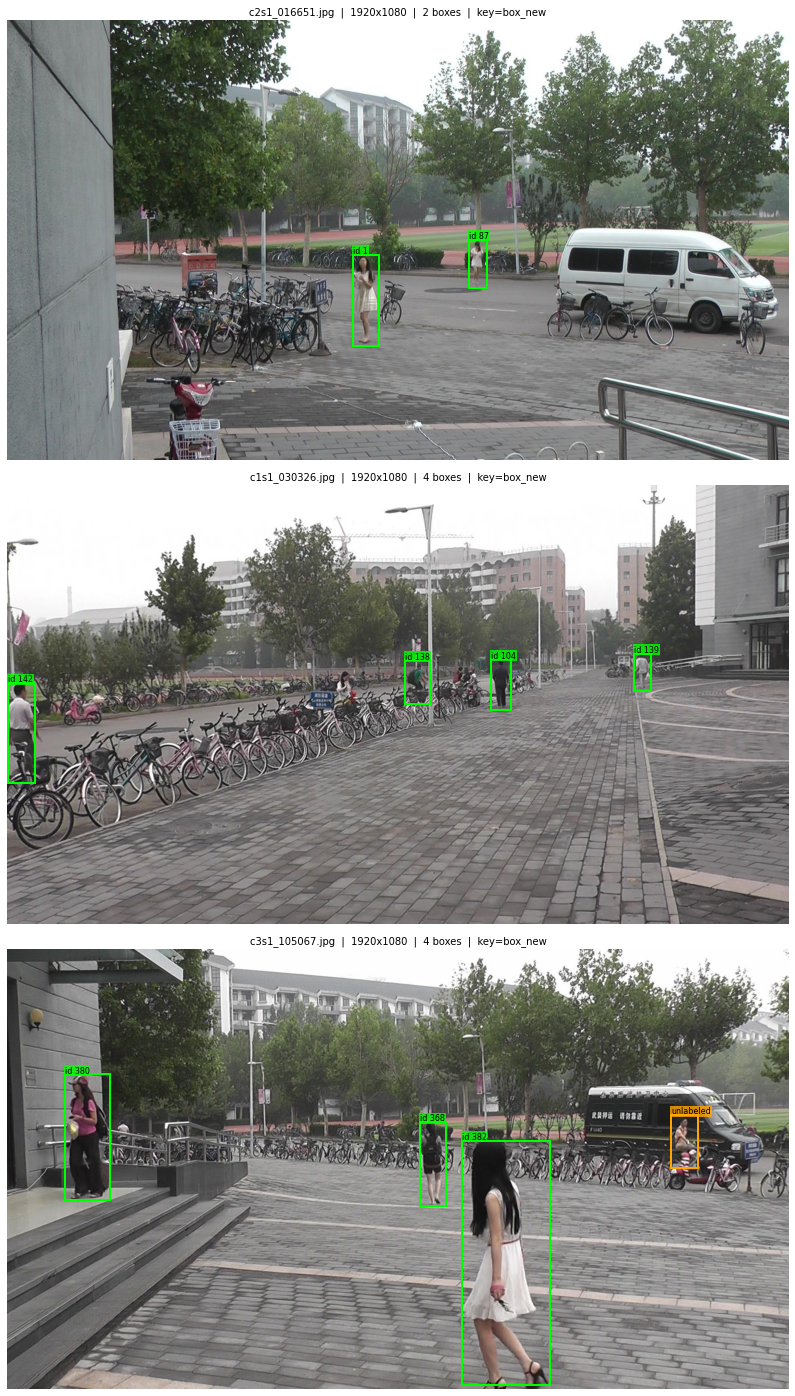

In [6]:
from src.sanity_check import render_sample_frames

fig = render_sample_frames(
    ROOT,
    prw.train_anns,
    out_path=os.path.join(FIG_DIR, "sample_frames_gt.png"),
    n=3,
    seed=SEED,
)

## 5. Identity map — the two id spaces

Two id spaces are kept strictly separate for the whole project:

* **raw pids** (including `-2`) — everything the professor's evaluation function touches, since it compares raw values;
* **contiguous ids** `[0 … L-1]` (plus `-1` for unlabeled) — training only: cross-entropy targets and OIM lookup-table rows.

The map is sized by the **count** of distinct labeled training identities, never by the maximum pid value. PRW's raw ids are sparse — they reach 933 while only 483 identities appear in training — so a lookup table sized by the maximum silently pushes identities into the wrong structure. `id_map.json` is written once and shared by every experiment row, so lookup-table indices and classifier classes always agree.

In [7]:
from src.prw_dataset import build_id_map, save_id_map

id_map = build_id_map(prw.train_anns)
save_id_map(id_map, "id_map.json")

raw = sorted(id_map)
print(f"L = {len(id_map)} labeled train identities -> [0, {len(id_map) - 1}]")
print(f"raw pid range: {raw[0]} .. {raw[-1]}  (sparse: {raw[-1] - len(raw)} values unused)")
print("first 5 mappings:", {p: id_map[p] for p in raw[:5]})
print("wrote id_map.json")

L = 483 labeled train identities -> [0, 482]
raw pid range: 1 .. 932  (sparse: 449 values unused)
first 5 mappings: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
wrote id_map.json


## 6. Train / validation split

PRW ships no validation split — the 570-frame split named in the brief does not exist in the published data — so we build one and freeze it in `split_v1.json`. Two properties, both deliberate:

* **frame-level, not crop-level.** Splitting crops would put different crops of the same person, often from the same scene, on both sides; the validation score would then measure memorisation.
* **identity-coverage-aware.** A frame may move to validation only if every labeled identity it contains keeps at least one frame on the training side. A plain random draw can strand a rare identity entirely in validation, removing it from the lookup table and from the classifier. Identities appearing in exactly one training frame can therefore never cross, so validation covers slightly fewer identities than training.

Seeded with 42 and written once — later components load this file and never regenerate it.

In [4]:
import json

from src.make_split import SPLIT_RULE, make_split, summarize

SPLIT_PATH = "split_v1.json"
VAL_SIZE = 570

if os.path.exists(SPLIT_PATH):
    with open(SPLIT_PATH, encoding="utf-8") as fh:
        split = json.load(fh)
    train_names, val_names = split["train"], split["val"]
    print(f"loaded existing {SPLIT_PATH} (rule={split['rule']}, seed={split['seed']})")
else:
    train_names, val_names = make_split(prw.train_anns, val_size=VAL_SIZE, seed=SEED)
    with open(SPLIT_PATH, "w", encoding="utf-8") as fh:
        json.dump(
            {
                "seed": SEED,
                "rule": SPLIT_RULE,
                "val_size": VAL_SIZE,
                "train": train_names,
                "val": val_names,
            },
            fh,
            indent=1,
        )
    print(f"wrote {SPLIT_PATH} (rule={SPLIT_RULE}, seed={SEED})")

stats = summarize(prw.train_anns, train_names, val_names)
for key, value in stats.items():
    print(f"  {key:<22} {value}")

assert len(train_names) + len(val_names) == len(prw.train_anns)
assert not (set(train_names) & set(val_names)), "a frame ended up on both sides"
assert stats["ids_only_in_val"] == 0, "an identity has no training frame left"
assert stats["val_frames"] == VAL_SIZE

loaded existing split_v1.json (rule=id_coverage_v1, seed=42)
  train_frames           5134
  val_frames             570
  train_ids              483
  val_ids                398
  ids_only_in_train      85
  ids_only_in_val        0
  train_labeled_crops    13369
  val_labeled_crops      1538
  train_unlabeled_crops  2811
  val_unlabeled_crops    330
  val_ids_with_ge2_crops 306


## 7. What the data actually says

Findings to carry into the write-up (each one is visible in the output above):

| finding | measured | brief / readme |
|---|---|---|
| labeled training identities | **483** | 482 |
| unlabeled training crops (`pid = -2`) | **3,141** | 2,827 |
| maximum raw pid | **933** | ids in `[1, 932]` |
| official validation split | **does not exist** | 570 frames |
| box key | varies per file: `box_new` 11,792 · `anno_file` 23 · `anno_previous` 1 | not documented |
| frame resolutions | 1920×1080 (8,918) and 720×576 (2,898) | not documented |
| total boxes, test boxes with / without id | 43,110 · 19,127 · 5,935 | matches exactly |

The 483 figure is not our parser being generous: `ID_train.mat` itself lists 483 identities, and the parsed set matches it exactly. Same for the queries — `ID_test.mat` (stored under the key `ID_test2`, not `ID_test`) lists exactly the 450 identities found in `query_info.txt`.

Two consequences for later steps:

* **The `h ≥ 24 px` crop filter never fires on training data** — the smallest labeled training crop is 63 px tall. The filter stays in the code as a guard, but it is not shaping the training set, so no train/test size mismatch is being introduced here.
* **18 identities have fewer than 4 crops**, so PK sampling with K=4 must sample those with replacement. That count is small enough that it is a footnote, not a design problem.

**Next step (M3): the detector.** `id_map.json` and `split_v1.json` are now frozen; everything downstream loads them rather than recomputing.

# Detector — M3

Person search is detection followed by re-identification. This section builds and fine-tunes the detection half: **torchvision Faster R-CNN R50-FPN, COCO weights, two classes (background + person)**.

Four choices worth defending:

* **R50-FPN.** The backbone the person-search literature standardises on (SeqNet, NAE and COAT all build on it), so our numbers are comparable to published ones, and it adds no dependency.
* **`min_size=900, max_size=1500`, aspect preserving.** 1500×900 is the standard PRW inference size. Squashing frames into a square destroys small pedestrians — exactly the boxes the gallery is full of.
* **`pid = -2` boxes are positive detection targets.** "Identity unknown" is a statement about re-identification, not about detection: those are real people, and training the detector to call them background would cost recall on the gallery. There are 2,811 such boxes in our training frames.
* **`trainable_backbone_layers=3`** — layer2–4 unfrozen, stem and layer1 frozen, frozen batch-norm throughout (torchvision's detection default).

**The checkpoint is selected on validation recall at IoU 0.5, not on COCO mAP.** The person-search metric matches at `iou_thresh = min(0.5, w·h/((w+10)(h+10)))` — never stricter than 0.5, and *more lenient* for small boxes — and it multiplies each query's average precision by the detector's recall for that identity. A box the detector never proposes is a recall loss the ranking can never repair, while tightening boxes beyond IoU 0.5 buys nothing the metric can see. Selecting on AP@0.75, as a prior project did, optimises something the final score cannot observe. This is a deliberate deviation from the usual detection recipe and is stated as such.

In [ ]:
import json

import matplotlib.pyplot as plt
import torch

from src import detector as det
from src.det_eval import print_recall_table, recall_at_iou, recall_table
from src.seed import device_report, set_seed

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch      ", torch.__version__)
print("device     ", device_report())

# Expensive steps are opt-in, so the notebook re-runs top to bottom without a GPU.
RUN_SMOKE = True                # 20-iteration overfit pre-gate, ~1 min on GPU
RUN_DETECTOR_TRAINING = False   # 12 epochs, ~1.5 h on a T4
RECOMPUTE_DETECTIONS = False    # inference passes; otherwise the cached .npz is reused

# Set by the Colab bootstrap to a Drive path, so a dropped runtime costs one
# epoch rather than the whole run; "checkpoints/detector" when running locally.
DET_DIR = CKPT_DIR
print("checkpoints", DET_DIR)

with open(SPLIT_PATH, encoding="utf-8") as fh:
    split = json.load(fh)
by_name = {a.img_name: a for a in prw.train_anns}
det_train_anns = [by_name[n] for n in split["train"]]
det_val_anns = [by_name[n] for n in split["val"]]
val_frame_names = [a.img_name for a in det_val_anns]
val_gts = [a.boxes for a in det_val_anns]

print(f"\ntrain frames {len(det_train_anns)} | val frames {len(det_val_anns)}")
print(f"train boxes  {sum(a.n_boxes for a in det_train_anns)} | val boxes  {sum(len(g) for g in val_gts)}")

In [6]:
model = det.build_detector()  # COCO weights, head replaced with 2 classes

n_all = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
heads = model.roi_heads

print(f"classes         : {heads.box_predictor.cls_score.out_features} (background + person)")
print(f"input size      : min={model.transform.min_size} max={model.transform.max_size} (aspect preserving)")
print(f"inference       : score>={heads.score_thresh}  dets/img={heads.detections_per_img}  nms={heads.nms_thresh}")
print(f"parameters      : {n_all / 1e6:.1f}M total, {n_trainable / 1e6:.1f}M trainable")

# What the model is actually fed: original-coordinate boxes, every box class 1.
train_ds = det.PRWDetectionDataset(ROOT, det_train_anns, train=True)
img, target = train_ds[0]
print(f"\nsample: image {tuple(img.shape)} | boxes {tuple(target['boxes'].shape)} | labels {target['labels'].tolist()}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Utente/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


  0%|          | 0.00/160M [00:00<?, ?B/s]

classes         : 2 (background + person)
input size      : min=(900,) max=1500 (aspect preserving)
inference       : score>=0.05  dets/img=50  nms=0.5
parameters      : 41.3M total, 41.1M trainable

sample: image (3, 1080, 1920) | boxes (2, 4) | labels [1, 1]


## 8.3 Pre-gate: can it overfit 8 frames?

Before spending an hour and a half of GPU time, 20 iterations on 8 frames. If the loss does not fall sharply here, something is wrong with the targets, the coordinate convention or the optimiser — and this costs a minute to find out instead of twelve epochs.

In [ ]:
if RUN_SMOKE:
    smoke_model = det.build_detector()
    history = det.overfit_smoke(smoke_model, train_ds, DEVICE, n_frames=8, iters=20)
    print(f"loss {history[0]:.4f} -> {history[-1]:.4f}  ({100 * (1 - history[-1] / history[0]):.0f}% drop)")

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(range(1, len(history) + 1), history, marker="o", ms=3)
    ax.set_xlabel("iteration")
    ax.set_ylabel("total loss")
    ax.set_title("overfit pre-gate: 8 frames, 20 iterations")
    ax.grid(alpha=0.3)
    del smoke_model
else:
    print("RUN_SMOKE = False (set it to True to run the pre-gate)")

## 8.4 Baseline: what does COCO give for free?

The off-the-shelf COCO detector already knows the class *person*, so it defines the zero-cost baseline: run it unchanged on the validation frames, keep class 1, measure the same recall. Fine-tuning then has to justify itself against this number rather than against nothing — and it costs one inference pass, not an ablation row.

Recall is reported at two detection-score thresholds: **0.5**, the literature default used for the headline numbers, and **0.05**, the threshold the shared inference pass runs at — the ceiling any later stage could reach.

In [ ]:
BASELINE_CACHE = os.path.join(CACHE_DIR, "det_val_coco_baseline.npz")

if RECOMPUTE_DETECTIONS or not os.path.exists(BASELINE_CACHE):
    coco_model = det.build_detector(num_classes=91)  # keep the original COCO head
    val_ds = det.PRWDetectionDataset(ROOT, det_val_anns, train=False)
    baseline_dets = det.predict(coco_model, val_ds, DEVICE, progress_every=25)
    det.save_detections(baseline_dets, val_frame_names, BASELINE_CACHE)
    del coco_model
    print(f"wrote {BASELINE_CACHE}")
else:
    cached = det.load_detections(BASELINE_CACHE)
    baseline_dets = [cached[n] for n in val_frame_names]
    print(f"loaded {BASELINE_CACHE}")

print_recall_table(
    recall_table(baseline_dets, val_gts, score_thrs=(0.05, 0.5)),
    title="\nCOCO Faster R-CNN, no fine-tuning, on PRW validation frames:",
)

## 8.5 Fine-tuning

SGD, lr 0.005, momentum 0.9, weight decay 5e-4, batch 4, 12 epochs, ×0.1 at epoch 8, default anchors. The learning rate is torchvision's reference detection recipe (0.02 at batch 16) rescaled linearly to batch 4; the anchors are left at their defaults, because hand-rolled anchor sizes were where a prior project's one real bug lived.

Every epoch writes a checkpoint and a CSV row, and training resumes from the last checkpoint — Colab sessions die mid-run, and a trainer that cannot resume loses the whole night. The same run is available from the command line:

```bash
python src/detector.py --root data --split split_v1.json --out-dir checkpoints/detector
```

In [ ]:
if RUN_DETECTOR_TRAINING:
    best_ckpt = det.train_detector(
        ROOT,
        det_train_anns,
        det_val_anns,
        out_dir=DET_DIR,
        epochs=12,
        batch_size=4,
        lr=0.005,
        milestones=(8,),
        device=DEVICE,
        seed=SEED,
    )
else:
    print("RUN_DETECTOR_TRAINING = False -- reading the saved log instead of training")

In [ ]:
import csv

log_path = os.path.join(DET_DIR, "log.csv")
if os.path.exists(log_path):
    with open(log_path, newline="", encoding="utf-8") as fh:
        log = [{k: float(v) for k, v in row.items()} for row in csv.DictReader(fh)]

    epochs = [r["epoch"] for r in log]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for key in ("loss", "loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"):
        if key in log[0]:
            axes[0].plot(epochs, [r[key] for r in log], label=key, lw=1.8 if key == "loss" else 1)
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("training loss")
    axes[0].set_title("detector training loss")
    axes[0].legend(fontsize=7)
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [r["val_recall@0.5"] for r in log], marker="o", ms=3, label="score >= 0.5")
    axes[1].plot(epochs, [r["val_recall@0.05"] for r in log], marker="o", ms=3, label="score >= 0.05")
    best = max(log, key=lambda r: r["val_recall@0.5"])
    axes[1].axvline(best["epoch"], color="grey", ls="--", lw=1)
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("val recall @ IoU 0.5")
    axes[1].set_title("validation recall (the selection criterion)")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    fig.tight_layout()

    print(f"best epoch: {int(best['epoch'])}  val recall@0.5 = {best['val_recall@0.5']:.4f}")
else:
    print(f"no training log at {log_path} yet -- run the cell above with RUN_DETECTOR_TRAINING = True")

## 8.6 Baseline vs. fine-tuned

The table the detector section exists to produce: same validation frames, same recall definition, COCO out of the box against our fine-tuned checkpoint.

In [ ]:
FT_CACHE = os.path.join(CACHE_DIR, "det_val_finetuned.npz")
best_path = os.path.join(DET_DIR, "best.pt")

if os.path.exists(FT_CACHE) and not RECOMPUTE_DETECTIONS:
    cached = det.load_detections(FT_CACHE)
    ft_dets = [cached[n] for n in val_frame_names]
    print(f"loaded {FT_CACHE}")
elif os.path.exists(best_path):
    ft_model = det.build_detector()
    ft_model.load_state_dict(det.load_checkpoint(best_path, map_location=DEVICE)["model"])
    val_ds = det.PRWDetectionDataset(ROOT, det_val_anns, train=False)
    ft_dets = det.predict(ft_model, val_ds, DEVICE, progress_every=25)
    det.save_detections(ft_dets, val_frame_names, FT_CACHE)
    del ft_model
    print(f"wrote {FT_CACHE}")
else:
    ft_dets = None
    print(f"no checkpoint at {best_path} yet -- train the detector first")

if ft_dets is not None:
    rows = []
    for name, dets in (("COCO, no fine-tuning", baseline_dets), ("fine-tuned on PRW", ft_dets)):
        r50 = recall_at_iou(dets, val_gts, score_thr=0.5)
        r05 = recall_at_iou(dets, val_gts, score_thr=0.05)
        rows.append((name, r50["recall"], r05["recall"], r50["det_per_frame"]))

    print(f"\n{'model':<24}{'recall@0.5':>12}{'recall@0.05':>13}{'det/frame@0.5':>15}")
    for name, r50, r05, dpf in rows:
        print(f"{name:<24}{r50:>12.4f}{r05:>13.4f}{dpf:>15.2f}")
    print(f"\ndelta from fine-tuning: {rows[1][1] - rows[0][1]:+.4f} recall @ score 0.5")

### Reading these numbers

* **recall @ 0.05 is the ceiling.** The shared inference pass runs at score 0.05 with at most 50 detections per frame, so no later stage — not the threshold sweep, not re-ranking — can retrieve a person missing from that pass.
* **recall @ 0.5 is what the headline numbers use**, and it is the criterion the checkpoint is selected on.
* **detections per frame** is the re-ID cost driver: the embedding pass has to crop and encode every one of them.

**Next (M4):** the re-ID data pipeline — crop datasets, augmentation, and the PK sampler that guarantees 12 identities × 4 crops per batch.